<a href="https://colab.research.google.com/github/Maxf85/LinearRegression/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
class LinearRegression:
    def __init__(self, lr=0.1, alpha=0.1):
        self.lr = lr
        self.alpha = alpha

    def fit(self, X_train, Y_train, X_val, Y_val, epochs=200, verbose=False):
        self.w = np.zeros(X_train.shape[1])
        self.b = 0
        self.train_mse_history = []
        self.val_mse_history = []

        for epoch in range(epochs):
            y_pred = self.predict(X_train)
            self.w += 2 * self.lr / len(X_train) * (Y_train - y_pred) @ X_train - 2 * self.alpha * self.w
            self.b += 2 * self.lr * (Y_train - y_pred).mean() - 2 * self.alpha * self.b

            train_preds = self.predict(X_train)
            val_preds = self.predict(X_val)

            train_mse = self.MSE(Y_train, train_preds)
            val_mse = self.MSE(Y_val, val_preds)

            self.train_mse_history.append(train_mse)
            self.val_mse_history.append(val_mse)

            if verbose:
                print(f"\nВеса после {epoch + 1} эпохи: w = {self.w}, b = {self.b}")
                print(f"MSE после {epoch + 1} эпохи: {val_mse}", train_mse)

    def MSE(self, Y, preds):
        return np.mean((Y - preds) ** 2)

    def predict(self, X):
        return X @ self.w + self.b


def grid_search_one_batch(X, y, lr_list, alpha_list, epochs_list):
    results = []
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    for lr in lr_list:
        for alpha in alpha_list:
            for epochs in epochs_list:
                model = LinearRegression(lr=lr, alpha=alpha)
                model.fit(X_train, y_train, X_val, y_val, epochs=epochs, verbose=False)
                results.append((lr, alpha, epochs, model.val_mse_history[-1]))
    return results

In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [ ]:
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']].values
y = df['median_house_value'].values / 1000

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

m = X_train.mean(axis=0)
s = X_train.std(axis=0)
X_train = (X_train - m) / s

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_test = (X_test - m) / s

In [ ]:
lr_list = [0.01, 0.05, 0.1]
alpha_list = [0.01, 0.05, 0.1]
epochs_list = [200, 500, 1000]

In [ ]:
results_one_batch = grid_search_one_batch(X_train, y_train, lr_list, alpha_list, epochs_list)
best_one_batch = min(results_one_batch, key=lambda x: x[3])

In [ ]:
print("Лучшие параметры для модели, где вся выборка - один большой батч:", best_one_batch)

Лучшие параметры для модели, где вся выборка - один большой батч: (0.1, 0.01, 1000, np.float64(5681.9595564862175))


In [ ]:
best_lr_one_batch, best_alpha_one_batch, best_epochs = best_one_batch[:3]
LR_one_batch = LinearRegression(lr=best_lr_one_batch, alpha=best_alpha_one_batch)
LR_one_batch.fit(X_train, y_train, X_val, y_val, epochs=best_epochs, verbose=True)


Веса после 1 эпохи: w = [-1.07559921 -3.30643211  2.36437302  3.0858044   1.04285057 -0.67392803
  1.35656985 16.23469866], b = 41.32475400735294
MSE после 1 эпохи: 38354.74679076839 38088.775472382

Веса после 2 эпохи: w = [-2.47698062 -5.77772355  4.88601267  4.67271582  1.3003417  -2.03994953
  1.86115616 28.71219917], b = 73.54518575748612
MSE после 2 эпохи: 27204.28304373945 26860.72641076373

Веса после 3 эпохи: w = [-3.93682508 -7.76907853  7.18511878  5.68372731  1.52829713 -3.37830596
  2.2831898  38.34741353], b = 98.66649816967471
MSE после 3 эпохи: 20145.791880038487 19781.01155630278

Веса после 4 эпохи: w = [-5.35920332 -9.44949808  9.19811888  6.36253853  1.83657463 -4.58253
  2.74324975 45.80144656], b = 118.25282944635525
MSE после 4 эпохи: 15630.266274975427 15272.55654974945

Веса после 5 эпохи: w = [ -6.70747428 -10.91458286  10.93119133   6.80510254   2.21737061
  -5.65929742   3.24210023  51.57415946], b = 133.52377782780627
MSE после 5 эпохи: 12705.790272993881 

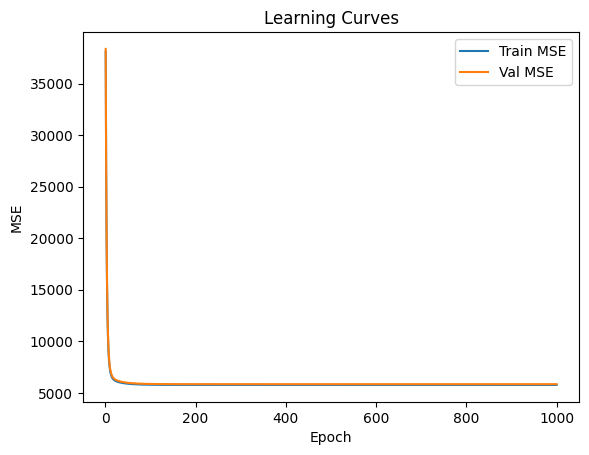

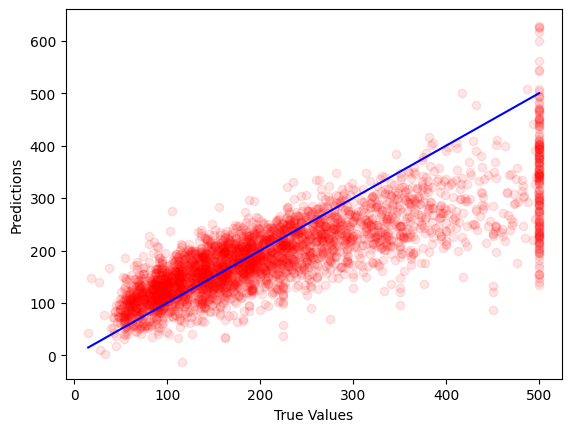

In [ ]:
def learning_curve(LR):
    plt.plot(range(1, len(LR.train_mse_history) + 1), LR.train_mse_history, label='Train MSE')
    plt.plot(range(1, len(LR.val_mse_history) + 1), LR.val_mse_history, label='Val MSE')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title('Learning Curves')
    plt.legend()
    plt.show()


learning_curve(LR_one_batch)

preds_one_batch = LR_one_batch.predict(X_test)
plt.scatter(y_test, preds_one_batch, color='red', alpha=0.1)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue')
plt.show()